In [1]:
import xarray
import pandas as pd
import numpy as np

import datetime

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.colors as mcolors
import matplotlib.dates as mdates

import glob
from scipy.interpolate import RegularGridInterpolator

kk = 630
ee = 820



# Open HSRL file here.

In [2]:
dat = '20190915'
base_date = pd.Timestamp('2019-09-15')
ds_nav = xarray.open_dataset(f'/home/svisaga/MUSICA_ANALYSES/WWW-AIR_1726704979598/CAMP2EX-HSRL2_P3B_{dat}_R0.h5', engine='h5netcdf', 
                             phony_dims='access', group='Nav_Data')
base_jday = ds_nav['Jday'][:,0].values[0]
day_deltas = ds_nav['Jday'][:,0].values - base_jday
time_deltas = pd.to_timedelta(ds_nav['gps_time'][:,0].values, unit='h')
dates = base_date + pd.to_timedelta(day_deltas, unit='D')
date_times = dates + time_deltas
formatted_dates = date_times.strftime('%Y-%m-%d %H:%M:%S')

ds_nav['Date'] = xarray.DataArray(
    formatted_dates,
    dims=["time"]
)

df_nav = ds_nav['Date'].to_dataframe().reset_index()
df_nav['time'] = pd.to_datetime(df_nav['time'])

dat = '20190915'
dat1 = '2019-09-15-03600'
dat2 = '2019-09-16-03600'
workdir = '/home/svisaga/MUSICA_ANALYSES/WWW-AIR_1726704979598/'
p3file = f'CAMP2Ex-mrg01-P3B-NC_merge_{dat}_R3.nc'
p3data_ds = xarray.open_dataset(workdir+p3file)

variables = ['AOT532_hi', 'MLH']
selected_data = p3data_ds[variables]
p3data = selected_data.to_dataframe().reset_index()
p3data['time'] = pd.to_datetime(p3data['time'].dt.strftime("%Y-%m-%d %H:%M:%S"))

df_nav_ = pd.merge(df_nav, p3data, on='time', how='inner')

ds_one = xarray.open_dataset(f'/home/svisaga/MUSICA_ANALYSES/WWW-AIR_1726704979598/CAMP2EX-HSRL2_P3B_{dat}_R0.h5', engine='h5netcdf', phony_dims='access', group='DataProducts')
variable_data = ds_one['532_ext']

# Open MUSICAv0 file here

In [3]:
def extract_level(df, lev):
    """
    Extract a single model level time series.
    lev: model level number (1–30)
    """
    return (
        df.loc[df['nl'] == (31 - lev), ['datetime', 'alt_mod']]
          .set_index('datetime')
          .to_xarray()
    )


In [4]:
file_pattern = '/home/svisaga/MUSICA_ANALYSES/curtain_tracks/hsrl_20190915_curtain_CAMP2Ex.nc'
file_list = glob.glob(file_pattern)
# Open multiple NetCDF files and combine them into a single dataset
ds = xarray.open_mfdataset(file_list,combine='by_coords')
ds = ds.isel(Date=slice(kk, ee))
# Calculate the average per altitude
average_per_altitude = ds.mean(dim='Date')
std_per_altitude = ds.std(dim='Date')


file_list = [
    "/home/svisaga/MUSICA_ANALYSES/curtain_tracks/p3_2019-09-15-03600_day1_curtain_MUSICAv0_7km_CAMP2Ex.nc",
    "/home/svisaga/MUSICA_ANALYSES/curtain_tracks/p3_2019-09-16-03600_day2_curtain_MUSICAv0_7km_CAMP2Ex.nc"
]

ds_mod = xarray.open_mfdataset(file_list,combine='by_coords')
common_dates = np.intersect1d(ds['Date'],ds_mod['datetime'].values)
ds_mod_ = ds_mod.sel(datetime=common_dates)
ds_mod_['datetime'] = pd.to_datetime(ds_mod_['datetime'].values)
variables = ['alt_mod', 'EXTINCT_mod']
ds_mod_ = ds_mod_[variables]
df_mod = ds_mod_.to_dataframe().reset_index()
df_mod['datetime'] = pd.to_datetime(df_mod['datetime'])
df_mod
constant_altitudes = ds.Altitude.values

# Create an empty DataFrame to store the resampled data
df_mod_interp = []

# Group the data by datetime
grouped = df_mod.groupby('datetime')

for name, group in grouped:
    # Sort by altitude to ensure monotonic input for interpolation
    group_sorted = group.sort_values('alt_mod')

    # Get min and max altitude for this group
    min_alt = group_sorted['alt_mod'].min()
    max_alt = group_sorted['alt_mod'].max()

    # Clip constant_altitudes to the valid range
    valid_altitudes = constant_altitudes[
        (constant_altitudes >= min_alt) & (constant_altitudes <= max_alt)
    ]

    # Interpolate only within the valid range
    interpolated = np.interp(valid_altitudes, group_sorted['alt_mod'], group_sorted['EXTINCT_mod'])

    # Create a DataFrame for the interpolated data
    interpolated_df = pd.DataFrame({
        'datetime': name,
        'altitude': valid_altitudes,
        'EXTINCT_mod': interpolated
    })

    df_mod_interp.append(interpolated_df)

df_mod_interp = pd.concat(df_mod_interp, ignore_index=True)
grouped_mean_ctrl = df_mod_interp.groupby('altitude').mean().reset_index()
grouped_std_ctrl = df_mod_interp.groupby('altitude').std().reset_index()


/tmp/ipykernel_1302054/3557576911.py:59: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  grouped_mean_ctrl = df_mod_interp.groupby('altitude').mean().reset_index()
/tmp/ipykernel_1302054/3557576911.py:60: FutureWarning: The default value of numeric_only in DataFrameGroupBy.std is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  grouped_std_ctrl = df_mod_interp.groupby('altitude').std().reset_index()


In [5]:
file_list = [
    "/home/svisaga/MUSICA_Paper1_figures_for_Exp01/curtain_tracks/p3_2019-09-15-03600_day1_curtain_MUSICAv0_7km_CAMP2Ex.nc",
    "/home/svisaga/MUSICA_Paper1_figures_for_Exp01/curtain_tracks/p3_2019-09-16-03600_day2_curtain_MUSICAv0_7km_CAMP2Ex.nc"
]

ds_mod = xarray.open_mfdataset(file_list,combine='by_coords')
common_dates = np.intersect1d(ds['Date'],ds_mod['datetime'].values)
ds_mod_ = ds_mod.sel(datetime=common_dates)
ds_mod_['datetime'] = pd.to_datetime(ds_mod_['datetime'].values)
variables = ['alt_mod', 'EXTINCT_mod', 'pblh_mod']
ds_mod_ = ds_mod_[variables]
df_mod = ds_mod_.to_dataframe().reset_index()
df_mod['datetime'] = pd.to_datetime(df_mod['datetime'])
constant_altitudes = ds.Altitude.values

# Create an empty DataFrame to store the resampled data
df_mod_interp = []

# Group the data by datetime
grouped = df_mod.groupby('datetime')

for name, group in grouped:
    # Sort by altitude to ensure monotonic input for interpolation
    group_sorted = group.sort_values('alt_mod')

    # Get min and max altitude for this group
    min_alt = group_sorted['alt_mod'].min()
    max_alt = group_sorted['alt_mod'].max()

    # Clip constant_altitudes to the valid range
    valid_altitudes = constant_altitudes[
        (constant_altitudes >= min_alt) & (constant_altitudes <= max_alt)
    ]

    # Interpolate only within the valid range
    interpolated = np.interp(valid_altitudes, group_sorted['alt_mod'], group_sorted['EXTINCT_mod'])

    # Create a DataFrame for the interpolated data
    interpolated_df = pd.DataFrame({
        'datetime': name,
        'altitude': valid_altitudes,
        'EXTINCT_mod': interpolated
    })

    df_mod_interp.append(interpolated_df)

df_mod_interp = pd.concat(df_mod_interp, ignore_index=True)
grouped_mean_exp01 = df_mod_interp.groupby('altitude').mean().reset_index()
grouped_std_exp01 = df_mod_interp.groupby('altitude').std().reset_index()


/tmp/ipykernel_1302054/1564652445.py:48: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  grouped_mean_exp01 = df_mod_interp.groupby('altitude').mean().reset_index()
/tmp/ipykernel_1302054/1564652445.py:49: FutureWarning: The default value of numeric_only in DataFrameGroupBy.std is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  grouped_std_exp01 = df_mod_interp.groupby('altitude').std().reset_index()


In [6]:
df_mod_pblh = df_mod[['datetime','pblh_mod']].drop_duplicates()
ds_mod_pblh_interp = df_mod_pblh.set_index(['datetime']).to_xarray()

ds_mod_interp = df_mod_interp.set_index(['datetime', 'altitude']).to_xarray()
curt_time = ds_mod_interp['datetime']
curt_time_np = np.array(curt_time, dtype='datetime64')
curt_time2 = np.tile(curt_time_np[:, np.newaxis], (1, ds_mod_interp['EXTINCT_mod'].shape[1]))

startdate_ = '2019-09-15 23:41:00'
enddate_ = '2019-09-16 00:13:00'
filedate_ = '0915_2341'
ds_mod_interp_ = ds_mod_interp.sel(datetime=slice(startdate_, enddate_))

levels_to_plot = range(15, 31)   # 15–30 inclusive

ds_levels = {
    lev: extract_level(df_mod, lev).sel(datetime=slice(startdate_, enddate_))
    for lev in levels_to_plot
}

ds_mod_pblh_interp_ = ds_mod_pblh_interp.sel(datetime=slice(startdate_, enddate_))

/home/svisaga/miniconda3/envs/cmp/lib/python3.11/site-packages/dask/array/numpy_compat.py:43: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


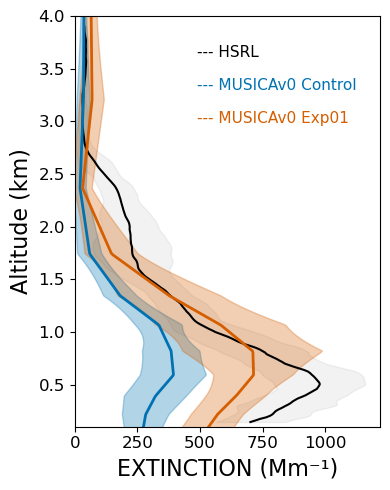

In [13]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# Precompute tick positions and labels once
# ---------------------------------------------------------
date_index = pd.DatetimeIndex(ds_nav['Date'][kk:ee].values)
lon_vals   = df_nav_['lon'].values[kk:ee]
mlh_vals   = df_nav_['MLH'].values[kk:ee]
time_vals  = df_nav_['time'].values[kk:ee]

tick_indices  = np.linspace(0, len(date_index) - 1, num=12, dtype=int)
tick_positions = date_index[tick_indices]
tick_labels    = [f"{lon_vals[i]:.2f}" for i in tick_indices]

# ---------------------------------------------------------
# Create 1 row × 3 column figure
# ---------------------------------------------------------
fig, (ax0) = plt.subplots(
    1, 1, figsize=(4, 5)
)
fig.subplots_adjust(wspace=-0.3)


# =========================================================
# PANEL (a) — Column 1: Extinction Profiles
# =========================================================

# HSRL mean + std
ax0.plot(average_per_altitude['hsrl_532_ext']*1000,
         average_per_altitude['Altitude']/1000,
         color='k')#, linewidth=1)

ax0.fill_betweenx(
    average_per_altitude['Altitude']/1000,
    1000*(average_per_altitude['hsrl_532_ext'] - std_per_altitude['hsrl_532_ext']),
    1000*(average_per_altitude['hsrl_532_ext'] + std_per_altitude['hsrl_532_ext']),
    color='gray', alpha=0.1
)

# MUSICAv0 Control
ax0.plot(grouped_mean_ctrl.EXTINCT_mod*1E6,
         grouped_mean_ctrl.altitude/1000,
         color='#0072B2', linewidth=2)

ax0.fill_betweenx(
    grouped_mean_ctrl.altitude/1000,
    1E6*(grouped_mean_ctrl.EXTINCT_mod - grouped_std_ctrl.EXTINCT_mod),
    1E6*(grouped_mean_ctrl.EXTINCT_mod + grouped_std_ctrl.EXTINCT_mod),
    color='#0072B2', alpha=0.3
)

# MUSICAv0 Exp01
ax0.plot(grouped_mean_exp01.EXTINCT_mod*1E6,
         grouped_mean_exp01.altitude/1000,
         color='#D55E00', linewidth=2)

ax0.fill_betweenx(
    grouped_mean_exp01.altitude/1000,
    1E6*(grouped_mean_exp01.EXTINCT_mod - grouped_std_exp01.EXTINCT_mod),
    1E6*(grouped_mean_exp01.EXTINCT_mod + grouped_std_exp01.EXTINCT_mod),
    color='#D55E00', alpha=0.3
)

# Text legend inside panel
ax0.text(0.4, 0.90, '--- HSRL', transform=ax0.transAxes, fontsize=11, color='k')
ax0.text(0.4, 0.82, '--- MUSICAv0 Control', transform=ax0.transAxes, fontsize=11, color='#0072B2')
ax0.text(0.4, 0.74, '--- MUSICAv0 Exp01', transform=ax0.transAxes, fontsize=11, color='#D55E00')


ax0.set_xlim(0, None)
ax0.set_ylim(0.1,4)
ax0.set_xlabel("EXTINCTION (Mm⁻¹)", fontsize=16)
ax0.set_ylabel("Altitude (km)", fontsize=16)
ax0.tick_params(labelsize=12)


plt.tight_layout()
plt.savefig("output/img/Figure7_AMSPaper_summary.png", dpi=300, bbox_inches="tight")


In [8]:
ds_levels[30]['datetime']

<xarray.DataArray 'datetime' (datetime: 190)>
array(['2019-09-15T23:41:07.000000000', '2019-09-15T23:41:17.000000000',
       '2019-09-15T23:41:27.000000000', '2019-09-15T23:41:37.000000000',
       '2019-09-15T23:41:47.000000000', '2019-09-15T23:41:57.000000000',
       '2019-09-15T23:42:07.000000000', '2019-09-15T23:42:17.000000000',
       '2019-09-15T23:42:27.000000000', '2019-09-15T23:42:37.000000000',
       '2019-09-15T23:42:47.000000000', '2019-09-15T23:42:57.000000000',
       '2019-09-15T23:43:07.000000000', '2019-09-15T23:43:17.000000000',
       '2019-09-15T23:43:27.000000000', '2019-09-15T23:43:37.000000000',
       '2019-09-15T23:43:47.000000000', '2019-09-15T23:43:57.000000000',
       '2019-09-15T23:44:07.000000000', '2019-09-15T23:44:17.000000000',
       '2019-09-15T23:44:27.000000000', '2019-09-15T23:44:37.000000000',
       '2019-09-15T23:44:47.000000000', '2019-09-15T23:44:57.000000000',
       '2019-09-15T23:45:07.000000000', '2019-09-15T23:45:17.000000000',
       '2019-09-15T23:45:27.000000000', '2019-09-15T23:45:37.000000000',
       '2019-09-15T23:45:47.000000000', '2019-09-15T23:45:57.000000000',
       '2019-09-15T23:46:07.000000000', '2019-09-15T23:46:17.000000000',
       '2019-09-15T23:46:27.000000000', '2019-09-15T23:46:37.000000000',
       '2019-09-15T23:46:47.000000000', '2019-09-15T23:46:57.000000000',
       '2019-09-15T23:47:07.000000000', '2019-09-15T23:47:17.000000000',
       '2019-09-15T23:47:27.000000000', '2019-09-15T23:47:37.000000000',
       '2019-09-15T23:47:47.000000000', '2019-09-15T23:47:57.000000000',
       '2019-09-15T23:48:07.000000000', '2019-09-15T23:48:17.000000000',
       '2019-09-15T23:48:27.000000000', '2019-09-15T23:48:37.000000000',
       '2019-09-15T23:48:47.000000000', '2019-09-15T23:48:57.000000000',
       '2019-09-15T23:49:07.000000000', '2019-09-15T23:49:17.000000000',
       '2019-09-15T23:49:27.000000000', '2019-09-15T23:49:37.000000000',
       '2019-09-15T23:49:47.000000000', '2019-09-15T23:49:57.000000000',
       '2019-09-15T23:50:07.000000000', '2019-09-15T23:50:17.000000000',
       '2019-09-15T23:50:27.000000000', '2019-09-15T23:50:37.000000000',
       '2019-09-15T23:50:47.000000000', '2019-09-15T23:50:57.000000000',
       '2019-09-15T23:51:07.000000000', '2019-09-15T23:51:17.000000000',
       '2019-09-15T23:51:27.000000000', '2019-09-15T23:51:37.000000000',
       '2019-09-15T23:51:47.000000000', '2019-09-15T23:51:57.000000000',
       '2019-09-15T23:52:07.000000000', '2019-09-15T23:52:17.000000000',
       '2019-09-15T23:52:27.000000000', '2019-09-15T23:52:37.000000000',
       '2019-09-15T23:52:47.000000000', '2019-09-15T23:52:57.000000000',
       '2019-09-15T23:53:07.000000000', '2019-09-15T23:53:17.000000000',
       '2019-09-15T23:53:27.000000000', '2019-09-15T23:53:37.000000000',
       '2019-09-15T23:53:47.000000000', '2019-09-15T23:53:57.000000000',
       '2019-09-15T23:54:07.000000000', '2019-09-15T23:54:17.000000000',
       '2019-09-15T23:54:27.000000000', '2019-09-15T23:54:37.000000000',
       '2019-09-15T23:54:47.000000000', '2019-09-15T23:54:57.000000000',
       '2019-09-15T23:55:07.000000000', '2019-09-15T23:55:17.000000000',
       '2019-09-15T23:55:27.000000000', '2019-09-15T23:55:37.000000000',
       '2019-09-15T23:55:47.000000000', '2019-09-15T23:55:57.000000000',
       '2019-09-15T23:56:07.000000000', '2019-09-15T23:56:17.000000000',
       '2019-09-15T23:56:27.000000000', '2019-09-15T23:56:37.000000000',
       '2019-09-15T23:56:47.000000000', '2019-09-15T23:56:57.000000000',
       '2019-09-15T23:57:07.000000000', '2019-09-15T23:57:17.000000000',
       '2019-09-15T23:57:27.000000000', '2019-09-15T23:57:37.000000000',
       '2019-09-15T23:57:47.000000000', '2019-09-15T23:57:57.000000000',
       '2019-09-15T23:58:07.000000000', '2019-09-15T23:58:17.000000000',
       '2019-09-15T23:58:27.000000000', '2019-09-15T23:58:37.000000000',
       '2019-09-15T23:58:47.000000000', '2019-09-15T23:58:57.000000000',
       '2019